<a href="https://colab.research.google.com/github/knight19720208ui/TIP_Taller_BigData/blob/main/Taller_BigData2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Instalación del motor (Tardará unos 40 segundos, es normal)
!pip install pyspark -q

In [2]:
from pyspark.sql import SparkSession

# Iniciamos el clúster en la nube
spark = SparkSession.builder \
    .appName("TIP_BigData_Lab") \
    .getOrCreate()

# Verificamos
print(f"¡Motor Spark encendido! Versión: {spark.version}")

¡Motor Spark encendido! Versión: 4.0.3


In [3]:
from pyspark.sql.functions import col, rand, when, floor
import pyspark.sql.functions as F

print("Generando 1,000,000 de registros...")
# Generamos datos sintéticos (Montos, Categorías, Horas)
df = spark.range(1000000).withColumn("monto", (rand() * 5000 + 10)) \
                         .withColumn("categoria", when(rand() < 0.3, "Electrónica")
                                              .when(rand() < 0.6, "Ropa")
                                              .otherwise("Alimentación")) \
                         .withColumn("hora_venta", floor(rand() * 24))

df = df.drop("id") # Limpiamos la columna auxiliar

print("Datos generados en memoria distribuida.")
df.printSchema() # Mostramos la estructura fuerte (tipado)

Generando 1,000,000 de registros...
Datos generados en memoria distribuida.
root
 |-- monto: double (nullable = false)
 |-- categoria: string (nullable = false)
 |-- hora_venta: long (nullable = true)



In [4]:
print("Ejecutando agregación distribuida (Group By)...")

# Agrupamos
df_agregado = df.groupBy("categoria", "hora_venta") \
    .agg(
        F.count("*").alias("num_transacciones"),
        F.round(F.avg("monto"), 2).alias("ticket_promedio")
    ).orderBy("categoria", "hora_venta")

# Acción: Mostrar los primeros resultados
df_agregado.show(15)

Ejecutando agregación distribuida (Group By)...
+------------+----------+-----------------+---------------+
|   categoria|hora_venta|num_transacciones|ticket_promedio|
+------------+----------+-----------------+---------------+
|Alimentación|         0|            11689|         2509.5|
|Alimentación|         1|            11581|        2497.02|
|Alimentación|         2|            11501|        2506.44|
|Alimentación|         3|            11468|        2526.31|
|Alimentación|         4|            11709|         2523.9|
|Alimentación|         5|            11633|        2518.43|
|Alimentación|         6|            11509|        2496.77|
|Alimentación|         7|            11594|        2532.01|
|Alimentación|         8|            11762|        2510.78|
|Alimentación|         9|            11598|        2522.11|
|Alimentación|        10|            11653|        2494.25|
|Alimentación|        11|            11779|        2496.24|
|Alimentación|        12|            11672|        2

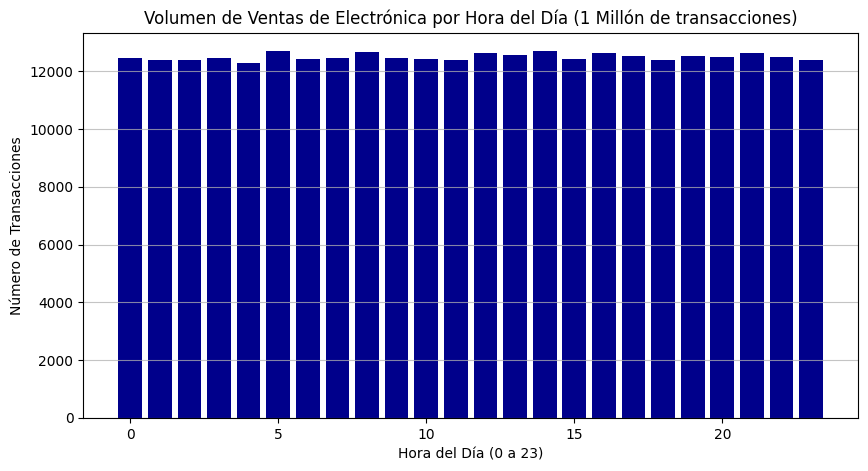

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# EL PUENTE: Pasamos el resultado pequeño (apenas 72 filas) de Spark a Pandas
df_pandas = df_agregado.toPandas()

# Filtramos solo una categoría para que el gráfico se vea limpio (Ej: Electrónica)
df_elec = df_pandas[df_pandas['categoria'] == "Electrónica"]

plt.figure(figsize=(10, 5))
plt.bar(df_elec['hora_venta'], df_elec['num_transacciones'], color='darkblue')
plt.title('Volumen de Ventas de Electrónica por Hora del Día (1 Millón de transacciones)')
plt.xlabel('Hora del Día (0 a 23)')
plt.ylabel('Número de Transacciones')
plt.grid(axis='y', alpha=0.75)
plt.show()